# Customer Segmentation — Wholesale Customers Dataset
**Assignment Six: Clustering — Theory and Practice (Part B)**

This notebook reproduces the Lesson 6 K-Means segmentation pipeline and adds a second
clustering algorithm (Agglomerative / Hierarchical Clustering) on the wholesale
customers dataset.


## Step 1 — Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

pd.set_option('display.max_columns', None)

df = pd.read_csv('raw_wholesale_customers.csv')
print("Checkpoint: dataset loaded ->", df.shape)
df.head()

Checkpoint: dataset loaded -> (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


## Step 2 — Select Features + IQR Capping

We cluster on the six spending columns only: `Fresh`, `Milk`, `Grocery`, `Frozen`,
`Detergents_Paper`, `Delicassen`. `Channel` and `Region` are excluded from the
feature set (kept aside for later interpretation/sanity checks).

We apply IQR capping (k = 1.5) to each spend column: values below Q1 - 1.5*IQR or
above Q3 + 1.5*IQR are clipped to the boundary — rows are never deleted.

In [3]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

df_capped = df.copy()

def iqr_cap(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return series.clip(lower=lower, upper=upper)

for col in spend_cols:
    df_capped[col] = iqr_cap(df_capped[col], k=1.5)

print("Checkpoint: IQR capping applied to", spend_cols)
df_capped[spend_cols].describe()

Checkpoint: IQR capping applied to ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.00000,440.000000,440.000000,440.000000
mean,11357.568182,5048.592045,7236.37500,2507.085795,2392.616477,1266.715341
std,10211.542235,4386.377073,6596.53308,2408.297738,2940.794090,1083.069792
min,3.000000,55.000000,3.00000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.00000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.50000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.75000,3554.250000,3922.000000,1820.250000
max,37642.750000,15676.125000,23409.87500,7772.250000,9419.875000,3938.250000


## Step 3 — Scale Features

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_capped[spend_cols])

print("Checkpoint: features scaled ->", X_scaled.shape)
pd.DataFrame(X_scaled, columns=spend_cols).describe().round(2)

Checkpoint: features scaled -> (440, 6)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.11,-1.14,-1.10,-1.03,-0.81,-1.17
25%,-0.81,-0.80,-0.77,-0.73,-0.73,-0.79
50%,-0.28,-0.32,-0.38,-0.41,-0.54,-0.28
75%,0.55,0.49,0.52,0.44,0.52,0.51
max,2.58,2.43,2.45,2.19,2.39,2.47


## Step 4 — Elbow Method (K = 1 to 10)

k= 1  SSE=2640.00
k= 2  SSE=1728.19
k= 3  SSE=1363.45
k= 4  SSE=1202.41
k= 5  SSE=1070.15
k= 6  SSE=964.76
k= 7  SSE=921.14
k= 8  SSE=776.63
k= 9  SSE=726.88
k=10  SSE=707.41


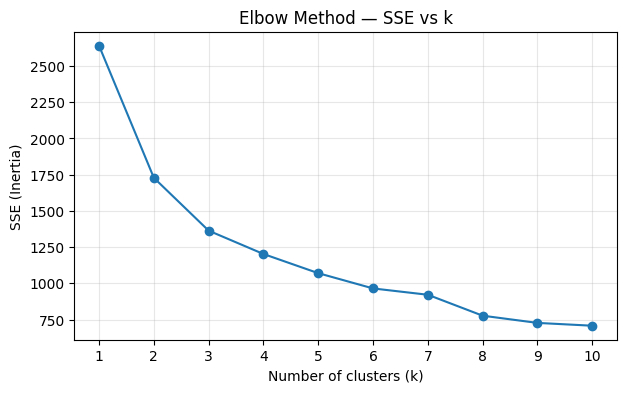

In [5]:
sse = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)
    print(f"k={k:2d}  SSE={km.inertia_:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method — SSE vs k')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()

## Step 5 — Train K-Means (Reproduce Lesson: k = 5)

In [6]:
kmeans = KMeans(n_clusters=5, n_init="auto", random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_capped['Cluster_KMeans'] = kmeans_labels

print("Checkpoint: K-Means fit complete")
df_capped['Cluster_KMeans'].value_counts().sort_index()

Checkpoint: K-Means fit complete

Cluster_KMeans
0     76
1    191
2     25
3     88
4     60
Name: count, dtype: int64

## Step 6 — Evaluate K-Means

In [7]:
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
dbi_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"K-Means Silhouette Score : {sil_kmeans:.4f}")
print(f"K-Means Davies-Bouldin Index : {dbi_kmeans:.4f}")

K-Means Silhouette Score : 0.2831
K-Means Davies-Bouldin Index : 1.2701


In [8]:
# Cluster centers in original spend units
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=spend_cols)
centers_df.index.name = 'Cluster'
print("Checkpoint: cluster centers converted back to original spend units")
centers_df.round(1)

Checkpoint: cluster centers converted back to original spend units


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,9202.7,6833.3,9104.1,1326.2,3280.1,1871.8
1,8376.2,2150.6,3160.6,1646.3,779.3,674.0
2,17461.5,13805.6,17524.1,4120.6,5460.6,3583.6
3,22346.7,3409.1,3969.3,5819.6,583.1,1566.9
4,4917.0,10768.9,18350.1,1212.4,7780.0,981.4


## Step 7 — Second Clustering Algorithm: Agglomerative (Hierarchical) Clustering

**Why this algorithm fits wholesale customer segmentation:** Hierarchical clustering
does not require assuming spherical, equally-sized clusters the way K-Means does,
and it produces a dendrogram that lets a distributor visually inspect how customer
segments merge at different similarity thresholds — useful for deciding how coarse
or fine-grained the segmentation should be. It also does not require randomly
initialized centroids, so results are deterministic given the linkage method.

**Source used:** scikit-learn's official user guide on hierarchical clustering
(`https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering`),
which explains agglomerative clustering and linkage criteria (ward, complete,
average, single).

We use Ward linkage (minimizes within-cluster variance, the standard default for
agglomerative clustering on continuous features) with 5 clusters, matching the
K-Means k for a fair comparison.

In [9]:
agglo = AgglomerativeClustering(n_clusters=5, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

df_capped['Cluster_Agglo'] = agglo_labels

print("Checkpoint: Agglomerative Clustering fit complete")
df_capped['Cluster_Agglo'].value_counts().sort_index()

Checkpoint: Agglomerative Clustering fit complete


Cluster_Agglo
0     70
1     72
2    164
3     55
4     79
Name: count, dtype: int64

## Step 8 — Compare Methods

In [10]:
sil_agglo = silhouette_score(X_scaled, agglo_labels)

print(f"K-Means Silhouette Score        : {sil_kmeans:.4f}")
print(f"Agglomerative Silhouette Score  : {sil_agglo:.4f}")

if sil_kmeans > sil_agglo:
    print("\nK-Means produced better-separated clusters (higher silhouette score).")
elif sil_agglo > sil_kmeans:
    print("\nAgglomerative Clustering produced better-separated clusters (higher silhouette score).")
else:
    print("\nBoth methods produced equally separated clusters.")

K-Means Silhouette Score        : 0.2831
Agglomerative Silhouette Score  : 0.2185

K-Means produced better-separated clusters (higher silhouette score).


## Step 9 — Sanity Check (3 Sample Clients)

In [11]:
sample_clients = df_capped.sample(3, random_state=42)
sample_clients[['Channel', 'Region'] + spend_cols + ['Cluster_KMeans', 'Cluster_Agglo']]

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster_KMeans,Cluster_Agglo
265,1,1,5909.0,15676.125,13699.0,7772.25,830.0,3636.0,2,0
78,1,3,10766.0,1175.000,2067.0,2096.00,301.0,167.0,1,2
347,2,3,27380.0,7184.000,12311.0,2809.00,4621.0,1022.0,0,0


## Step 10 — Save Output

In [12]:
output = df.copy()
output['Cluster'] = kmeans_labels
output.to_csv('segmented_wholesale_customers.csv', index=False)

print("Checkpoint: saved segmented_wholesale_customers.csv ->", output.shape)
output.head()

Checkpoint: saved segmented_wholesale_customers.csv -> (440, 9)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,3
4,2,3,22615,5410,7198,3915,1777,5185,3
